# Would I have survived the Titanic

In [1]:
import pandas as pd

# preprocessing functions
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures

# pipeline functions
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer



In [2]:
# load titanic data

url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Practice/master/Data/titanic.csv'
data = pd.read_csv(url)

In [3]:
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


 ## Function Transformer

It makes functions compatible with scikit-learn pipelines.

We are going to add two new features: title and family size.

In [4]:
data.Name[0].split(',')[1].split('.')[0].strip() # the title (strip removes blank spaces)

'Mr'

In [5]:
titles = data.Name.apply(lambda name:name.split(',')[1].split('.')[0].strip())

<AxesSubplot:>

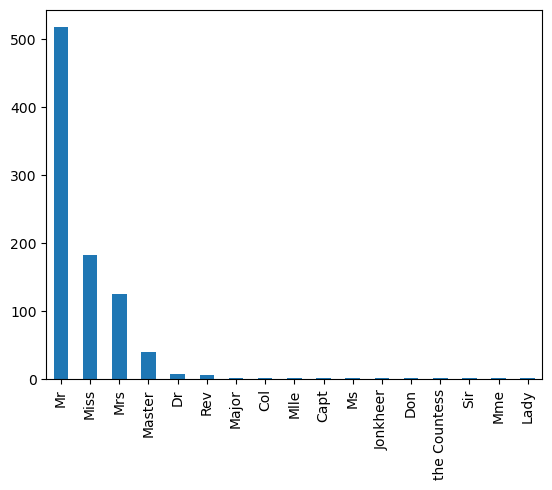

In [6]:
titles.value_counts().plot.bar()

In [7]:
# replace less common titles with 'other'
most_common_titles = titles.value_counts().head(6).index.to_list()

most_common_titles

['Mr', 'Miss', 'Mrs', 'Master', 'Dr', 'Rev']

<AxesSubplot:>

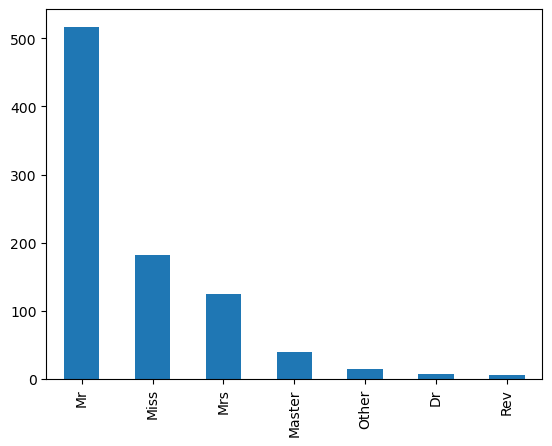

In [8]:
# repleace less common titles with 'other'
titles[~titles.isin(most_common_titles)] = 'Other'
titles.value_counts().plot.bar()

In [9]:
def get_title(data):
    df = data.copy() # so that we don't modify the original dataframe
    df['title'] = df.Name.apply(lambda name:name.split(',')[1].split('.')[0].strip())
    most_common_titles = df.title.value_counts().head(6).index.to_list()
    df.loc[~df.title.isin(most_common_titles),'title'] = 'Other'
    return df

In [10]:
data.SibSp

0      1
1      1
2      0
3      1
4      0
      ..
886    0
887    0
888    1
889    0
890    0
Name: SibSp, Length: 891, dtype: int64

In [11]:
get_title_processor = FunctionTransformer(get_title)

In [12]:
get_title_processor.fit(data)
get_title_processor.transform(data)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rev
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Mr


In [13]:
# get family_size function
def get_family_size(data):
    df = data.copy()
    df['family_size'] = df.SibSp + df.Parch + 1 
    return df

In [14]:
get_family_size(data)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,family_size
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,4
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1


In [15]:
family_size_preprocessor = FunctionTransformer(get_family_size)

In [16]:
family_size_preprocessor.fit_transform(data)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,family_size
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,4
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1


## Pipelines and Column Transformer 

Pipleline applies sequentially a list of transformations
ColumnTransformer applies in parallel transformations to the columns

In [17]:
# numerical features pipeline
num_features = ['Age', 'Fare', 'Pclass', 'family_size']

num_processor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler())
])
num_processor

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', MinMaxScaler())])

In [18]:
# categorical pipeline
cat_features = ['Sex','Embarked','title']
cat_processor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
cat_processor

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

In [19]:
feature_processor = ColumnTransformer(transformers=[
    ('num', num_processor, num_features),
    ('cat', cat_processor, cat_features)
],remainder='drop') # drop name, SibSP, and Parch (un-transformed columns)
feature_processor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', MinMaxScaler())]),
                                 ['Age', 'Fare', 'Pclass', 'family_size']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Sex', 'Embarked', 'title'])])

In [20]:
from sklearn.neighbors import KNeighborsClassifier

In [21]:
knn_clf = KNeighborsClassifier()

In [22]:
# classification pipeline
pipe_clf = Pipeline(steps=[
    ('get_title', get_title_processor),
    ('family_size', family_size_preprocessor),
    ('processor', feature_processor),
    ('poly_features', PolynomialFeatures()),
    ('clf',knn_clf)
])
pipe_clf

Pipeline(steps=[('get_title',
                 FunctionTransformer(func=<function get_title at 0x7f7c20eebca0>)),
                ('family_size',
                 FunctionTransformer(func=<function get_family_size at 0x7f7c12e19d30>)),
                ('processor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['Age', 'Fare', 'Pclass',
                                                   'family_size']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked',
                                                   'title'])])),
                ('poly_features', PolynomialFeatures()),
                ('clf', KNeighborsClassifier())])

## Grid Search

In [23]:
# feature matrix / target vector

y = data.Survived
X = data.drop(['PassengerId', 'Survived', 'Ticket', 'Cabin'], axis=1)

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y)

In [25]:
from sklearn.model_selection import GridSearchCV

In [26]:
# parameter values dictionary
# step in pipeline + __ (two underscores)

params_dic = {
    'poly_features__degree':[1,2],
    'clf__n_neighbors':list(range(5,30)),
    'clf__weights':['uniform', 'distance']
}

In [27]:
grid = GridSearchCV(pipe_clf,
                    params_dic,
                    cv = 5, # number of folds in cross validation
                    scoring='accuracy', # evaluation metric
                    n_jobs = -1, # use all CPU's of computer
                    verbose=1,
                    error_score='raise'
)

In [28]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('get_title',
                                        FunctionTransformer(func=<function get_title at 0x7f7c20eebca0>)),
                                       ('family_size',
                                        FunctionTransformer(func=<function get_family_size at 0x7f7c12e19d30>)),
                                       ('processor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          MinMaxScaler())]),
                                                                         ['...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Sex',
                                                                          'Embarked',
                                                                          'title'])])),
                                       ('poly_features', PolynomialFeatures()),
                                       ('clf', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'clf__n_neighbors': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14,
                                              15, 16, 17, 18, 19, 20, 21, 22,
                                              23, 24, 25, 26, 27, 28, 29],
                         'clf__weights': ['uniform', 'distance'],
                         'poly_features__degree': [1, 2]},
             scoring='accuracy', verbose=1)

In [29]:
family_size_preprocessor.fit_transform(X_train)

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,family_size
611,3,"Jardin, Mr. Jose Neto",male,NaN,0,0,7.0500,S,1
774,2,"Hocking, Mrs. Elizabeth (Eliza Needs)",female,54.0,1,3,23.0000,S,5
81,3,"Sheerlinck, Mr. Jan Baptist",male,29.0,0,0,9.5000,S,1
651,2,"Doling, Miss. Elsie",female,18.0,0,1,23.0000,S,2
91,3,"Andreasson, Mr. Paul Edvin",male,20.0,0,0,7.8542,S,1
...,...,...,...,...,...,...,...,...,...
782,1,"Long, Mr. Milton Clyde",male,29.0,0,0,30.0000,S,1
129,3,"Ekstrom, Mr. Johan",male,45.0,0,0,6.9750,S,1
526,2,"Ridsdale, Miss. Lucy",female,50.0,0,0,10.5000,S,1
239,2,"Hunt, Mr. George Henry",male,33.0,0,0,12.2750,S,1


In [30]:
X_train.SibSp

611    0
774    1
81     0
651    0
91     0
      ..
782    0
129    0
526    0
239    0
882    0
Name: SibSp, Length: 668, dtype: int64

In [31]:
get_title_processor.fit_transform(X_train).SibSp

611    0
774    1
81     0
651    0
91     0
      ..
782    0
129    0
526    0
239    0
882    0
Name: SibSp, Length: 668, dtype: int64